In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Chargement des données
df = pd.read_csv("cves_enriched_local.csv")

# Nettoyage rapide
df = df.dropna(subset=["Score Score Score Score Score Score Score CVSS", "Score EPSS"])
df = df[df["Score CVSS"] != "Non disponible"]
df = df[df["Score EPSS"] != "Non disponible"]
df["Score CVSS"] = df["Score CVSS"].astype(float)
df["Score EPSS"] = df["Score EPSS"].astype(float)

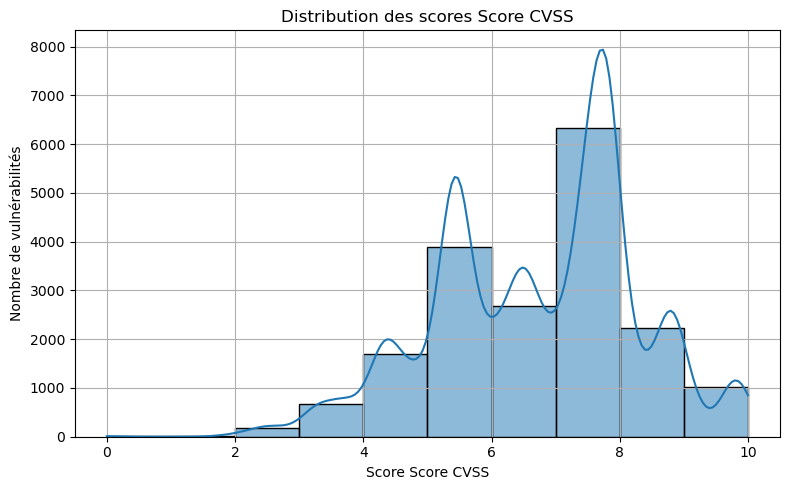

In [3]:
# Histogramme des scores Score CVSS
plt.figure(figsize=(8, 5))
sns.histplot(df["Score CVSS"], bins=10, kde=True)
plt.title("Distribution des scores Score CVSS")
plt.xlabel("Score Score CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.grid(True)
plt.tight_layout()
plt.savefig("cvss_distribution.png")
plt.show()

C:\Users\antoi\AppData\Local\Temp\ipykernel_28744\806102107.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  epss_means = df.groupby('cvss_bin')['Score EPSS'].mean().reset_index()


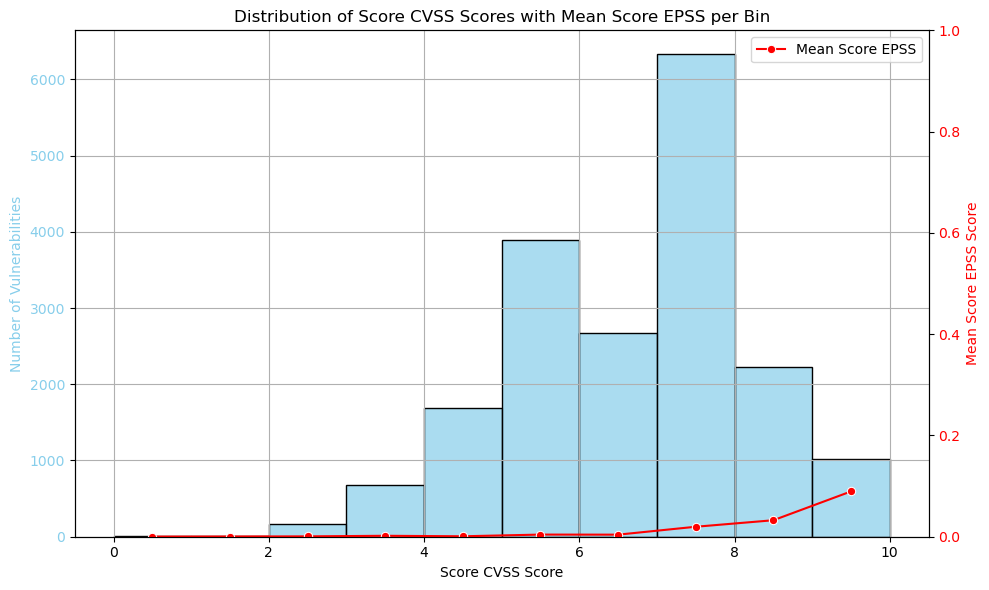

In [4]:
df['cvss_bin'] = pd.cut(df['Score CVSS'], bins=10)

# Calculate mean Score EPSS for each Score CVSS bin
epss_means = df.groupby('cvss_bin')['Score EPSS'].mean().reset_index()
epss_means['cvss_mid'] = epss_means['cvss_bin'].apply(lambda x: x.mid)

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Histogram of Score CVSS scores (left axis)
sns.histplot(df['Score CVSS'], bins=10, kde=False, ax=ax1, color='skyblue', alpha=0.7)
ax1.set_xlabel('Score CVSS Score')
ax1.set_ylabel('Number of Vulnerabilities', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.grid(True)

# Line plot of mean Score EPSS (right axis)
ax2 = ax1.twinx()
sns.lineplot(x='cvss_mid', y='Score EPSS', data=epss_means, 
             ax=ax2, color='red', marker='o', label='Mean Score EPSS')
ax2.set_ylabel('Mean Score EPSS Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1)  # Score EPSS ranges from 0 to 1

# Title and legend
plt.title('Distribution of Score CVSS Scores with Mean Score EPSS per Bin')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig("cvss_distribution_with_epss.png")
plt.show()

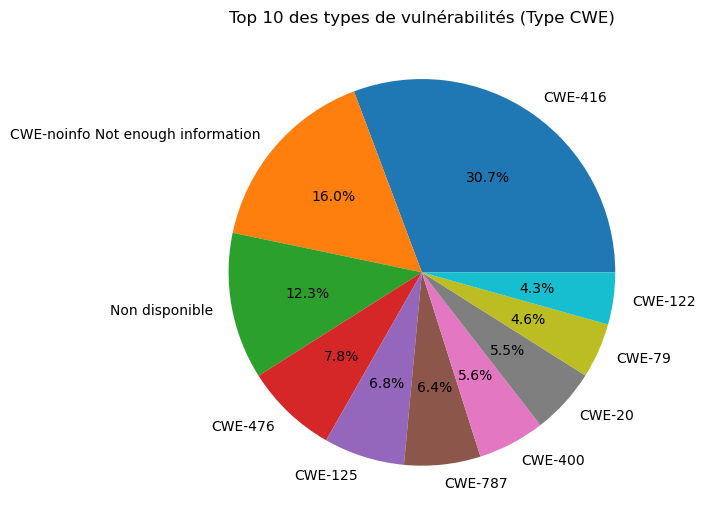

In [5]:
# Diagramme circulaire des types Type CWE
top_cwe = df["Type CWE"].value_counts().head(10)
plt.figure(figsize=(7, 7))
top_cwe.plot.pie(autopct="%1.1f%%")
plt.title("Top 10 des types de vulnérabilités (Type CWE)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("cwe_pie.png")
plt.show()

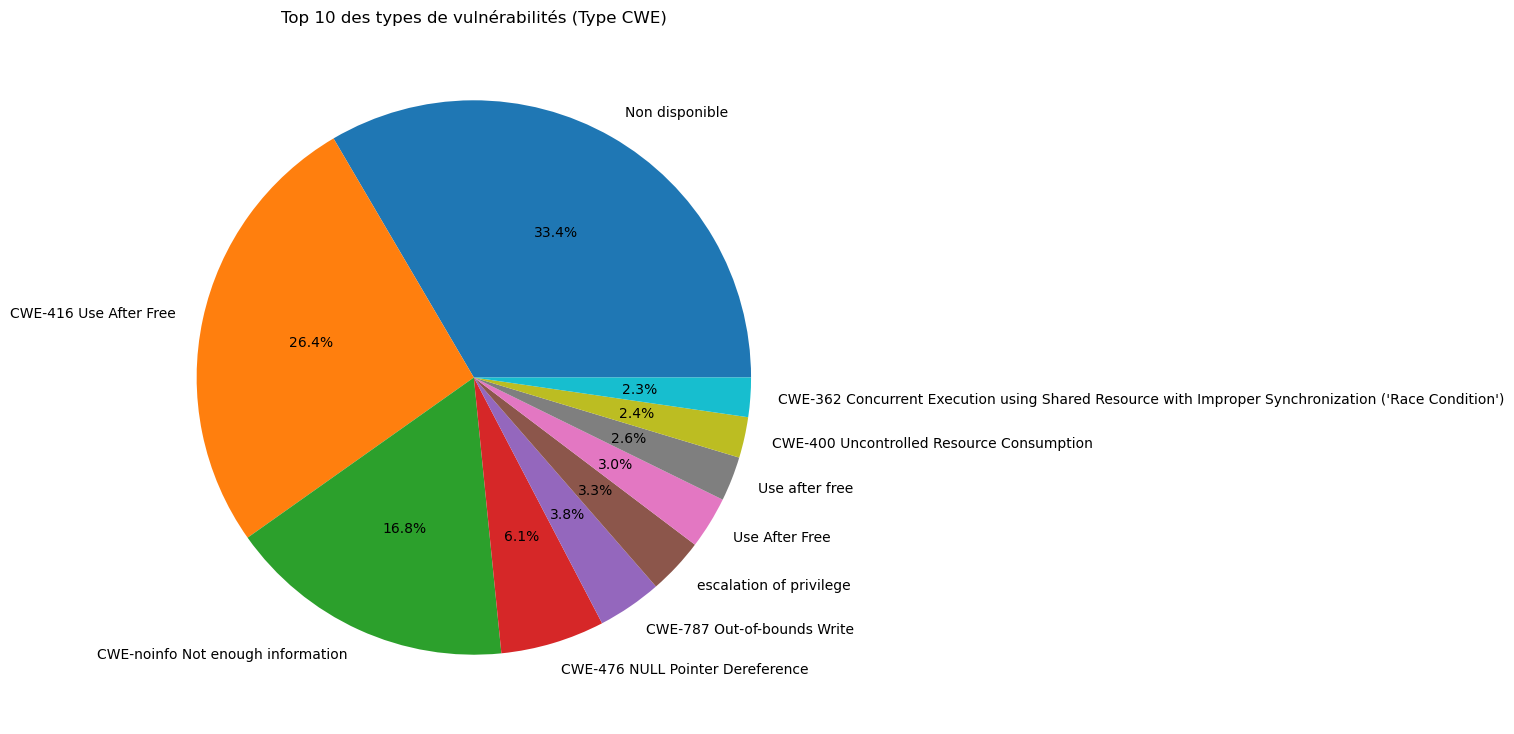

In [6]:
# Diagramme circulaire des types Type CWE
top_cwe = df["Description CWE"].value_counts().head(10)
plt.figure(figsize=(9, 9))
top_cwe.plot.pie(autopct="%1.1f%%")
plt.title("Top 10 des types de vulnérabilités (Type CWE)")
plt.ylabel("")

plt.savefig("cwe_desc_pie.png")
plt.show()

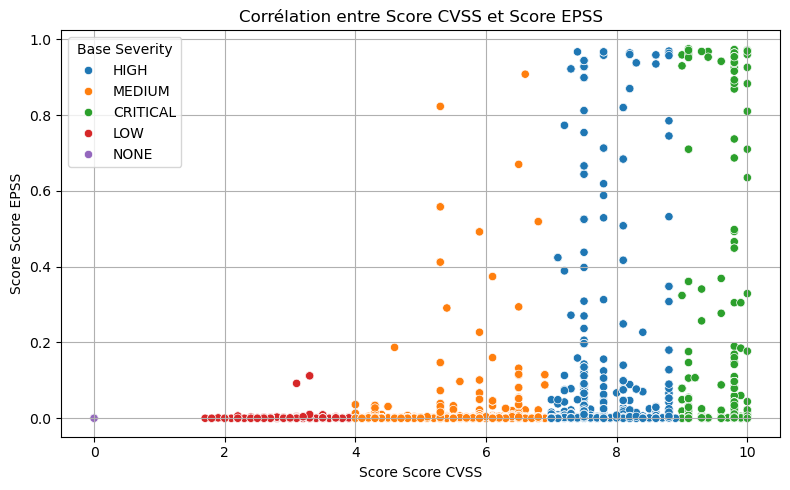

In [7]:
# Nuage de points Score CVSS vs Score EPSS
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Score CVSS", y="Score EPSS", data=df, hue="Base Severity")
plt.title("Corrélation entre Score CVSS et Score EPSS")
plt.xlabel("Score Score CVSS")
plt.ylabel("Score Score EPSS")
plt.grid(True)
plt.tight_layout()
plt.savefig("scatter_cvss_epss.png")
plt.show()

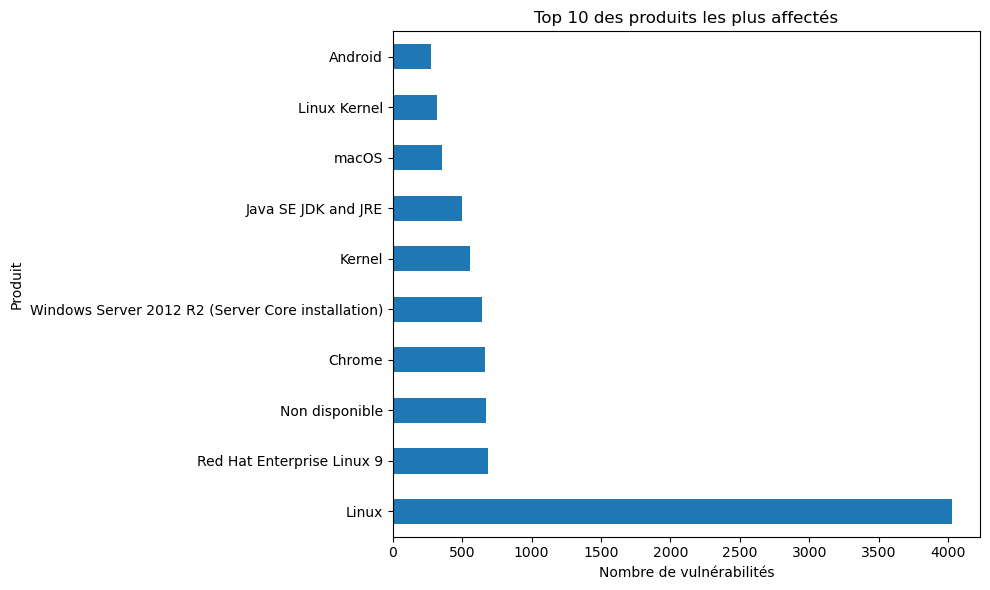

In [8]:
# Produits les plus affectés
plt.figure(figsize=(10, 6))
df["Produit"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 des produits les plus affectés")
plt.xlabel("Nombre de vulnérabilités")
plt.tight_layout()
plt.savefig("top_products.png")
plt.show()

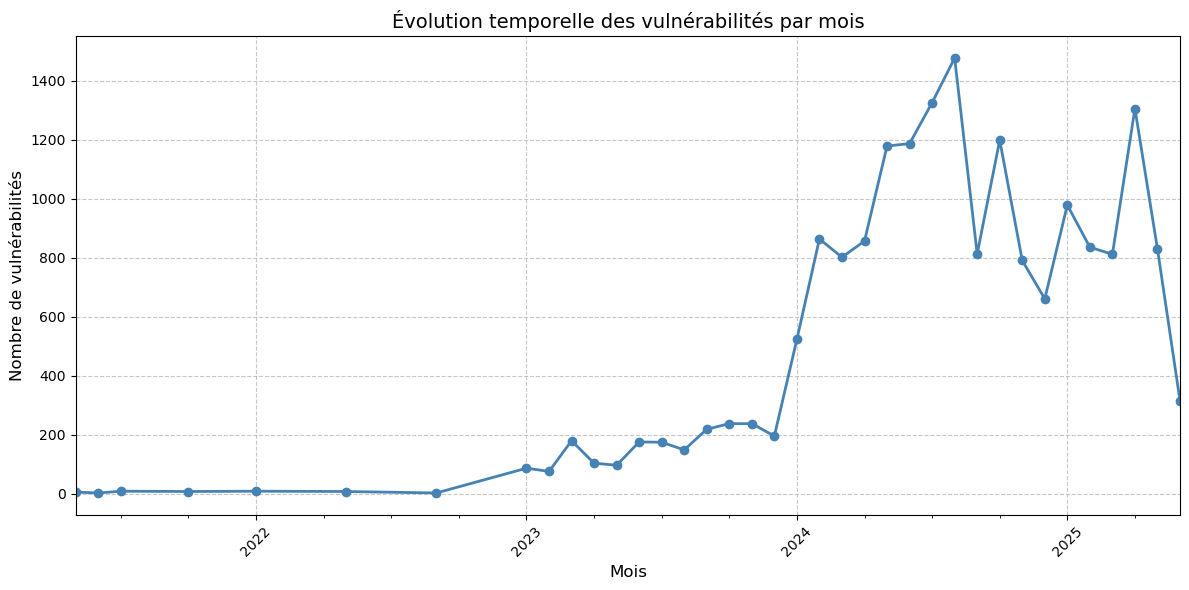

In [19]:
# Handle date conversion with potential time components
try:
    # First try parsing with ISO format (includes time)
    df["Date de publication"] = pd.to_datetime(df["Date de publication"], format='ISO8601')
except ValueError:
    try:
        # If that fails, try parsing just the date part
        df["Date de publication"] = pd.to_datetime(df["Date de publication"].str.split('T').str[0])
    except AttributeError:
        # If the split fails, try the most flexible parser
        df["Date de publication"] = pd.to_datetime(df["Date de publication"], format='mixed')

# Now group by month
df_by_month = df.groupby(df["Date de publication"].dt.to_period("M")).size()

# Plot the evolution
plt.figure(figsize=(12, 6))
df_by_month.plot(kind="line", marker="o", color='steelblue', linewidth=2)
plt.title("Évolution temporelle des vulnérabilités par mois", fontsize=14)
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Nombre de vulnérabilités", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

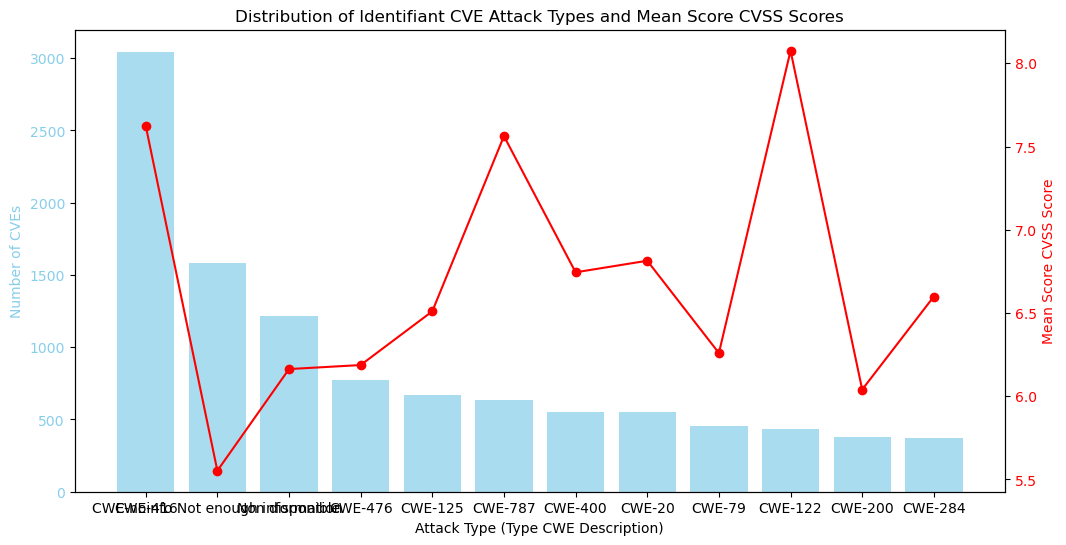

In [15]:

#rapport entre type d'attaques et sévérité
attack_stats = df.groupby('Type CWE').agg(
    count=('Identifiant CVE', 'size'),
    mean_cvss=('Score CVSS', 'mean')
).sort_values(by='count', ascending=False).reset_index().head(12)
fig, ax1 = plt.subplots(figsize=(12, 6))
# Bar plot (frequency of attack types)
ax1.bar(attack_stats['Type CWE'], attack_stats['count'], color='skyblue', alpha=0.7, label='Number of CVEs')
ax1.set_xlabel('Attack Type (Type CWE Description)')
ax1.set_ylabel('Number of CVEs', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Line plot (mean Score CVSS)
ax2 = ax1.twinx()
ax2.plot(attack_stats['Type CWE'], attack_stats['mean_cvss'], color='red', marker='o', label='Mean Score CVSS')
ax2.set_ylabel('Mean Score CVSS Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and legend
plt.title('Distribution of Identifiant CVE Attack Types and Mean Score CVSS Scores')
plt.savefig("mean_cvss_per_cve.png")
plt.show()

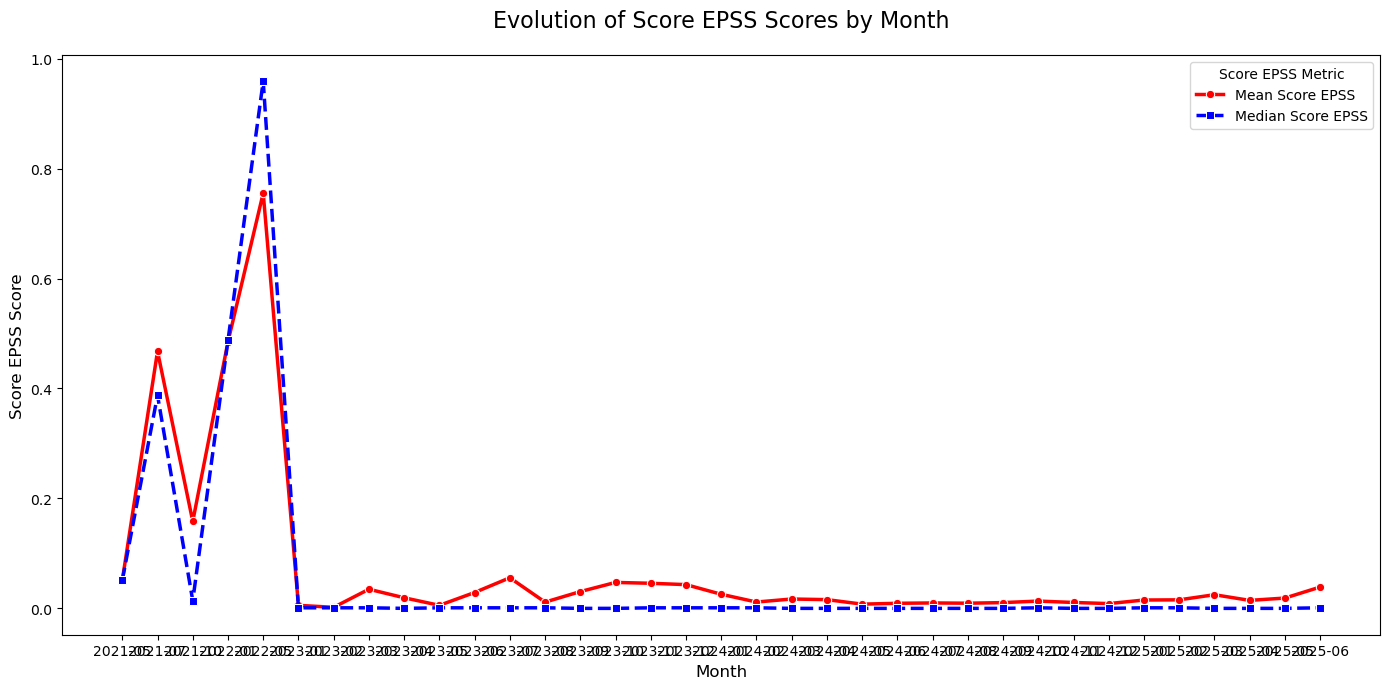

In [30]:
#moyenne Score EPSS par mois (proba/frequence d'attaque)
df['Date de publication'] = pd.to_datetime(df['Date de publication'])
df['year_month'] = df['Date de publication'].dt.to_period('M')
df['Score EPSS'] = pd.to_numeric(df['Score EPSS'], errors='coerce')
monthly_stats = df.groupby('year_month')['Score EPSS'].agg(['mean', 'median', 'count']).reset_index()
monthly_stats['year_month'] = monthly_stats['year_month'].astype(str)
monthly_stats = monthly_stats[monthly_stats['count'] >= 4]
plt.figure(figsize=(14, 7))
sns.lineplot(x='year_month', y='mean', data=monthly_stats, 
             marker='o', color='red', linewidth=2.5, label='Mean Score EPSS')
sns.lineplot(x='year_month', y='median', data=monthly_stats,
             marker='s', color='blue', linewidth=2.5, linestyle='--', label='Median Score EPSS')
plt.title('Evolution of Score EPSS Scores by Month', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Score EPSS Score', fontsize=12)
plt.legend(title='Score EPSS Metric')
plt.tight_layout()
plt.savefig('epss_trend_by_month.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\antoi\AppData\Local\Temp\ipykernel_28744\2507122476.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  epss_means = df.groupby('cvss_bin')['Score EPSS'].mean().reset_index()


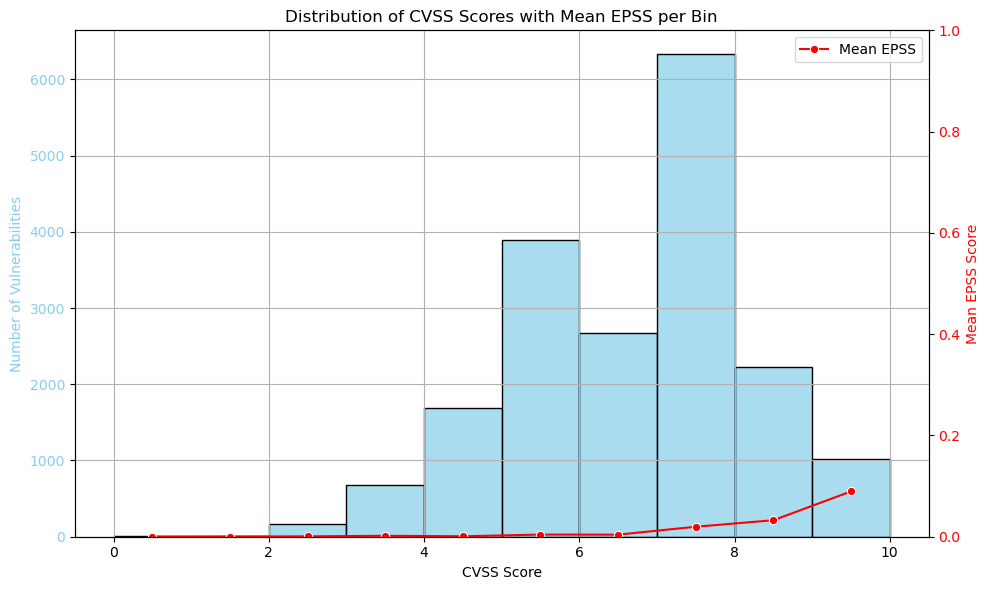

In [31]:

# Create CVSS bins
df['cvss_bin'] = pd.cut(df['Score CVSS'], bins=10)

# Calculate mean EPSS for each CVSS bin
epss_means = df.groupby('cvss_bin')['Score EPSS'].mean().reset_index()
epss_means['cvss_mid'] = epss_means['cvss_bin'].apply(lambda x: x.mid)

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Histogram of CVSS scores (left axis)
sns.histplot(df['Score CVSS'], bins=10, kde=False, ax=ax1, color='skyblue', alpha=0.7)
ax1.set_xlabel('CVSS Score')
ax1.set_ylabel('Number of Vulnerabilities', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.grid(True)

# Line plot of mean EPSS (right axis)
ax2 = ax1.twinx()
sns.lineplot(x='cvss_mid', y='Score EPSS', data=epss_means, 
             ax=ax2, color='red', marker='o', label='Mean EPSS')
ax2.set_ylabel('Mean EPSS Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1)  # EPSS ranges from 0 to 1

# Title and legend
plt.title('Distribution of CVSS Scores with Mean EPSS per Bin')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig("cvss_distribution_with_epss.png")
plt.show()

C:\Users\antoi\AppData\Local\Temp\ipykernel_28744\901554536.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=product_stats.index, y='mean', data=product_stats,
C:\Users\antoi\AppData\Local\Temp\ipykernel_28744\901554536.py:28: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  points = sns.pointplot(x=product_stats.index, y='max', data=product_stats,


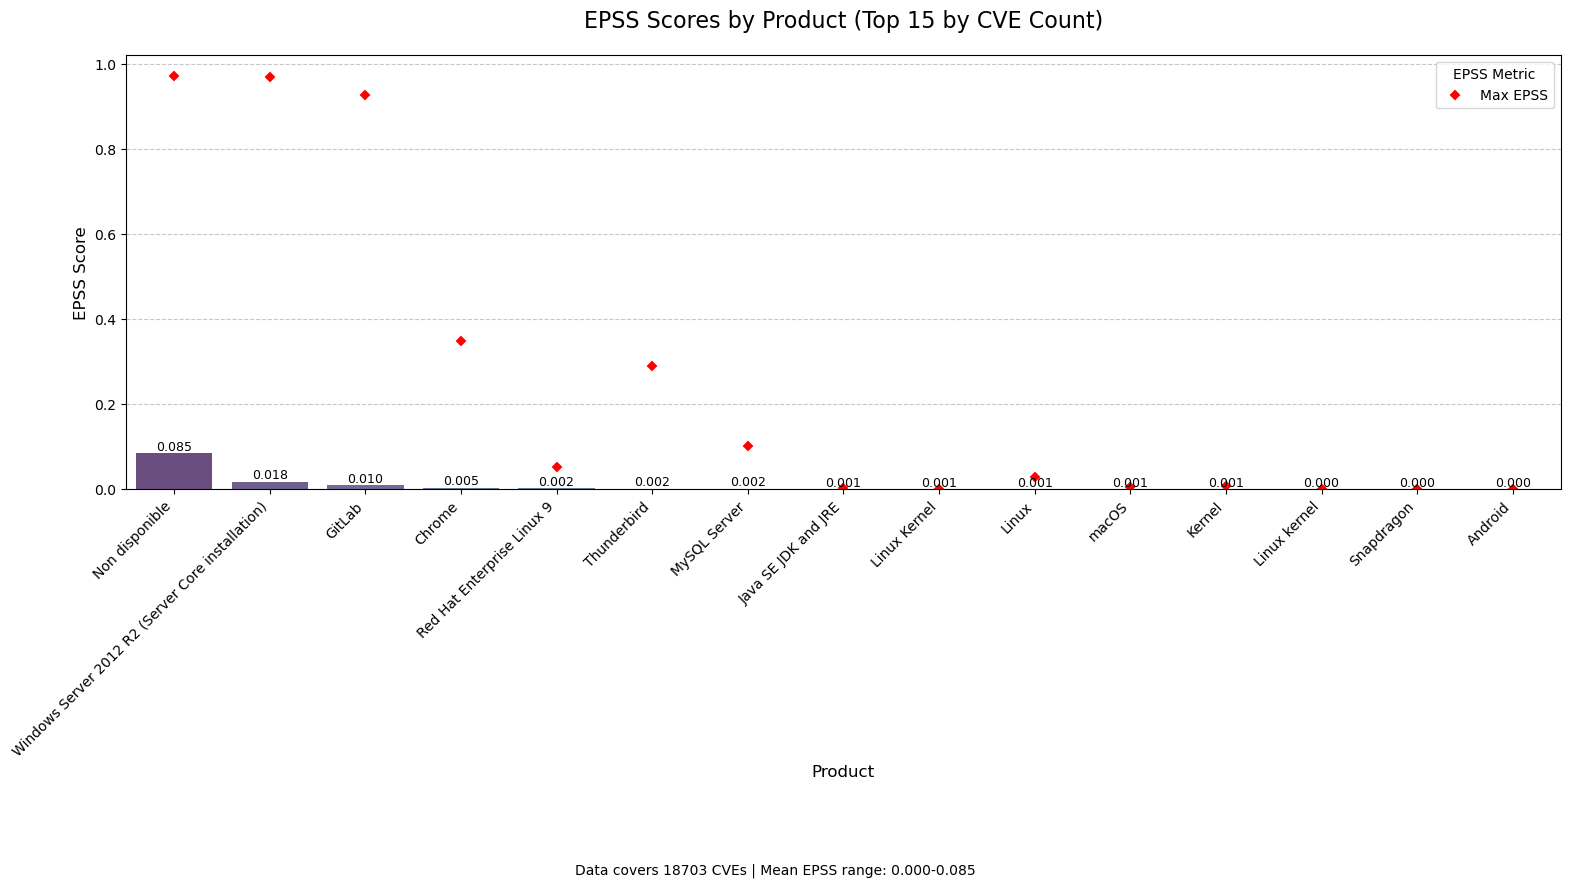

EPSS Statistics by Product:


,mean,median,count,max
Produit,,,,
Non disponible,0.085,0.001,671,0.971
Windows Server 2012 R2 (Server Core installation),0.018,0.001,644,0.969
GitLab,0.010,0.000,194,0.926
Chrome,0.005,0.001,664,0.348
Red Hat Enterprise Linux 9,0.002,0.000,687,0.053
Thunderbird,0.002,0.000,221,0.291
MySQL Server,0.002,0.000,218,0.101
Java SE JDK and JRE,0.001,0.000,497,0.004
Linux Kernel,0.001,0.001,318,0.002


In [ ]:
#EPSS score by top 15 products
df['Score EPSS'] = pd.to_numeric(df['Score EPSS'], errors='coerce')
df = df.dropna(subset=['Score EPSS'])

top_products = df['Produit'].value_counts().head(15).index

product_stats = df[df['Produit'].isin(top_products)].groupby('Produit')['Score EPSS'].agg(
    ['mean', 'median', 'count', 'max']
).sort_values('mean', ascending=False)

plt.figure(figsize=(16, 8))

bars = sns.barplot(x=product_stats.index, y='mean', data=product_stats, 
                   palette='viridis', alpha=0.8)

for bar in bars.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

points = sns.pointplot(x=product_stats.index, y='max', data=product_stats,
                       color='red', markers='D', linestyles='', scale=0.7,
                       label='Max EPSS')

plt.title('EPSS Scores by Product (Top 15 by CVE Count)', fontsize=16, pad=20)
plt.xlabel('Product', fontsize=12)
plt.ylabel('EPSS Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.legend(title='EPSS Metric')
plt.tight_layout()

plt.figtext(0.5, -0.1, 
            f"Data covers {len(df)} CVEs | Mean EPSS range: {product_stats['mean'].min():.3f}-{product_stats['mean'].max():.3f}", 
            ha='center', fontsize=10)

plt.savefig('epss_by_product.png', dpi=300, bbox_inches='tight')
plt.show()

print("EPSS Statistics by Product:")
display(product_stats.style
       .background_gradient(subset=['mean'], cmap='YlOrRd')
       .format({'mean': '{:.3f}', 'median': '{:.3f}', 'max': '{:.3f}'}))

C:\Users\antoi\AppData\Local\Temp\ipykernel_28744\2060400070.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


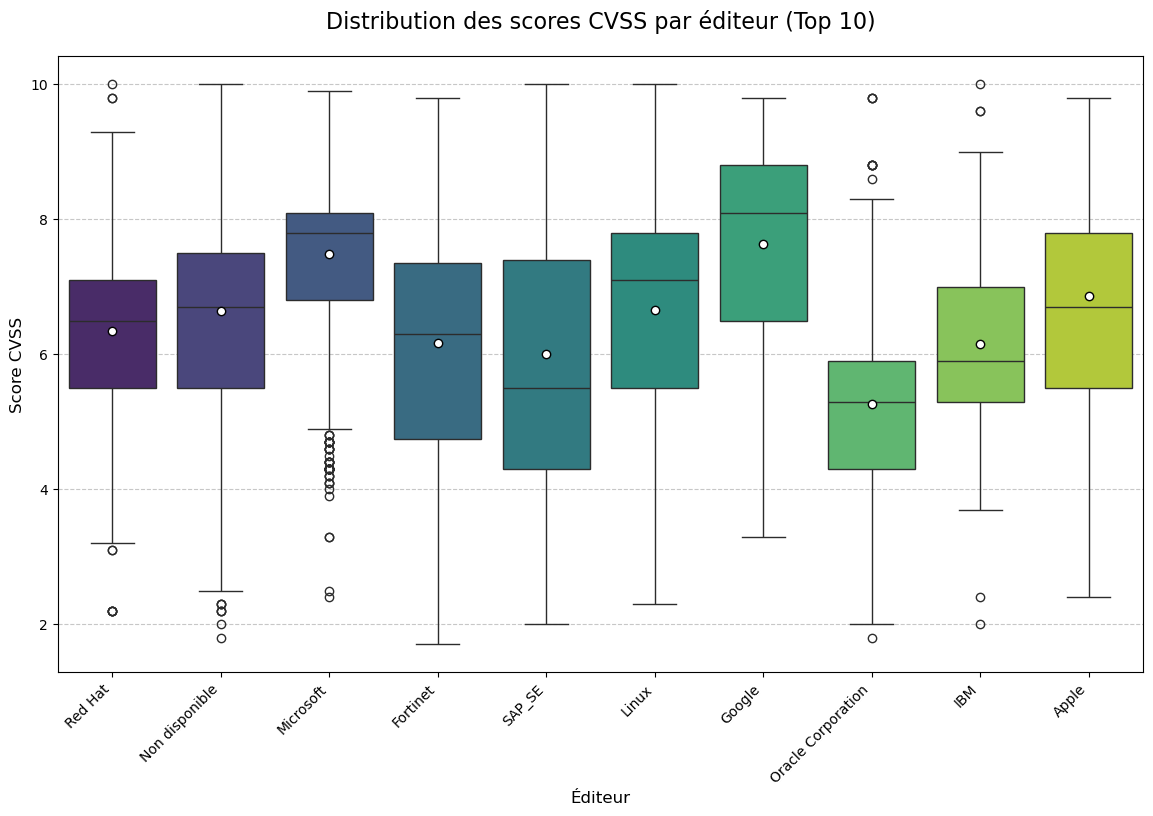

In [29]:

# Data preparation
# Convert CVSS to numeric and filter valid values
df['Score CVSS'] = pd.to_numeric(df['Score CVSS'], errors='coerce')
df = df.dropna(subset=['Score CVSS'])

# Get top Éditeur/Vendors by CVE count (adjust number as needed)
top_ÉditeurVendors = df['Éditeur/Vendor'].value_counts().head(10).index

# Filter for top Éditeur/Vendors
df_top_ÉditeurVendors = df[df['Éditeur/Vendor'].isin(top_ÉditeurVendors)]

# Create the boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(
    x='Éditeur/Vendor', 
    y='Score CVSS', 
    data=df_top_ÉditeurVendors,
    palette='viridis',
    showmeans=True,
    meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black'}
)


# Customize the plot
plt.title('Distribution des scores CVSS par éditeur (Top 10)', fontsize=16, pad=20)
plt.xlabel('Éditeur', fontsize=12)
plt.ylabel('Score CVSS', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)



plt.savefig('cvss_boxplot_par_editeur.png', dpi=300, bbox_inches='tight')
plt.show()
